In [19]:
import numpy as np
from pathlib import Path
import pandas as pd
from torch import nn
import torch

In [88]:
def read_PES(file: str | Path):
    filename = Path(file)
    pes = np.loadtxt(filename)
    df = pd.DataFrame(
        pes,
        columns=["r12","r13","r23","Eab"]
    )
    return df

def read_3b(file: str | Path):
    filename = Path(file)
    pes = np.loadtxt(filename)
    df = pd.DataFrame(
        pes,
        columns=["r12","r23","r13","Eab"]
    )
    return df

In [95]:
pes_ab = read_PES("/home/jorgebdelafuente/Doctorado/PH2M/Sings/1SAp.dat")
# pes = read_3b("/home/jorgebdelafuente/Doctorado/Fit_PH2M/1SAp/3body.dat")
V_target = pes["Eab"].to_numpy(dtype=float).reshape(-1, 1)

pes_ab.query("r23 == 1.4 & r12 >= 17.0 & r13 >= 17.0")
# pes.query("r12 > 20.0 & r13 > 20.0") # & r23 == 1.40 ")

,r12,r13,r23,Eab
4742,17.014406,17.014406,1.4,-341.575459
4751,19.012890,19.012890,1.4,-341.575434
4752,18.891029,19.133976,1.4,-341.575431
4755,20.012246,20.012246,1.4,-341.575426
4756,18.772114,19.250655,1.4,-341.575423
4757,19.890396,20.133359,1.4,-341.575423
4760,19.771531,20.250100,1.4,-341.575416
4761,18.659850,19.359494,1.4,-341.575411
4763,19.659349,20.359027,1.4,-341.575406
4771,18.469251,19.541412,1.4,-341.575380


In [31]:
def gen_exponents(max_order,include_constant=False):
    exponents = []
    min_order = 0 if include_constant else 1

    for M in range(min_order,max_order+1):
        for l12 in range(M,-1,-1):
            for l13 in range(l12,-1,-1):
                l23 = M - l12 - l13

                if l23 < 0:
                    continue

                exponents.append((l12,l13,l23))
    return exponents

def gen_pips(r12,r13,r23,
            alpha_ph,alpha_hh,
            max_order,include_constant=False):

    r12 = np.asarray(r12,dtype=float)
    r13 = np.asarray(r13,dtype=float)
    r23 = np.asarray(r23,dtype=float)

    pi12 = np.exp(-alpha_ph*r12) 
    pi13 = np.exp(-alpha_ph*r13) 
    pi23 = np.exp(-alpha_hh*r23) 

    exponents = gen_exponents(max_order=max_order,include_constant=include_constant)

    pips = [] ; labels = []
    for l12,l13,l23 in exponents:
        original = (pi12**l12 * pi13**l13 * pi23**l23)

        if l12 == l13:
            G = original
        else: 
            permuted = (pi12**l13 * pi13**l12 * pi23**l23)

            G = original + permuted

        pips.append(G) ; labels.append(f"G_{l12}{l13}{l23}")

    # row -> geom ; pip -> column
    pips = np.column_stack(pips)

    return pips,labels


In [32]:
r12 = pes["r12"].to_numpy(dtype=float)
r13 = pes["r13"].to_numpy(dtype=float)
r23 = pes["r23"].to_numpy(dtype=float)

X, pip_names = gen_pips(
    r12=r12,
    r13=r13,
    r23=r23,
    alpha_ph=1.0,
    alpha_hh=1.0,
    max_order=2,
    include_constant=False,
)

print(pip_names)
print(X.shape)

['G_100', 'G_001', 'G_200', 'G_110', 'G_101', 'G_002']
(24894, 6)


In [33]:
X_original, _ = gen_pips(
    r12, r13, r23,
    alpha_ph=1.0,
    alpha_hh=1.0,
    max_order=2,
)

X_swapped, _ = gen_pips(
    r13, r12, r23,
    alpha_ph=1.0,
    alpha_hh=1.0,
    max_order=2,
)

assert np.allclose(X_original, X_swapped)

print("Simetría H1 <-> H2 verificada")

Simetría H1 <-> H2 verificada


In [34]:
model = nn.Sequential(
    nn.Linear(X.shape[1],32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.Tanh(),
    nn.Linear(32,1)
)

In [35]:
X_tensor = torch.tensor(X, dtype=torch.float64)

model = model.double()

with torch.no_grad():
    V_pred = model(X_tensor)

print(V_pred)

tensor([[0.0920],
        [0.0923],
        [0.0920],
        ...,
        [0.0867],
        [0.0867],
        [0.0867]], dtype=torch.float64)


In [39]:
# Dividir los datos
rng = np.random.default_rng(1234)
indices = rng.permutation(len(X))

n_train = int(0.6*len(X)) ; n_val = int(0.3*len(X)) 

idx_train = indices[:n_train] ; idx_val = indices[n_train:n_train+n_val] ; idx_test = indices[n_train+n_val:]

X_train = X[idx_train] ; X_val = X[idx_val] ; X_test = X[idx_test]
V_train = V_target[idx_train] ; V_val = V_target[idx_val] ; V_test = V_target[idx_test]

In [40]:
X_mean = X_train.mean(axis=0) ; X_std = X_train.std(axis=0)

X_std[X_std == 0.0] = 1.0

V_mean = V_train.mean(axis=0) ; V_std = V_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

V_train_scaled = (V_train - V_mean) / V_std
V_val_scaled = (V_val - V_mean) / V_std
V_test_scaled = (V_test - V_mean) / V_std

In [41]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float64)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float64)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float64)

V_train_tensor = torch.tensor(V_train_scaled, dtype=torch.float64)
V_val_tensor = torch.tensor(V_val_scaled, dtype=torch.float64)
V_test_tensor = torch.tensor(V_test_scaled, dtype=torch.float64)

In [42]:
# Red y optimizador ¿?
model = nn.Sequential(
    nn.Linear(X.shape[1], 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1),
).double()

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0e-3,
)

In [43]:
n_epochs = 5000

for epoch in range(n_epochs):

    # Modo entrenamiento
    model.train()

    # Predicción con los pesos actuales
    V_pred_train = model(X_train_tensor)

    # Error respecto a los valores reales
    train_loss = loss_function(
        V_pred_train,
        V_train_tensor,
    )

    # Borra gradientes anteriores
    optimizer.zero_grad()

    # Calcula cómo debe cambiar cada peso
    train_loss.backward()

    # Actualiza los pesos
    optimizer.step()

    # Validación
    model.eval()

    with torch.no_grad():
        V_pred_val = model(X_val_tensor)

        val_loss = loss_function(
            V_pred_val,
            V_val_tensor,
        )

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"train = {train_loss.item():.6e} | "
            f"validation = {val_loss.item():.6e}"
        )

Epoch     0 | train = 1.313423e+00 | validation = 1.316702e+00
Epoch   100 | train = 1.664389e-01 | validation = 1.684849e-01
Epoch   200 | train = 1.043079e-01 | validation = 1.071817e-01
Epoch   300 | train = 9.774139e-02 | validation = 1.004542e-01
Epoch   400 | train = 9.236387e-02 | validation = 9.492216e-02
Epoch   500 | train = 8.685817e-02 | validation = 8.915813e-02
Epoch   600 | train = 8.086259e-02 | validation = 8.281861e-02
Epoch   700 | train = 7.419253e-02 | validation = 7.581236e-02
Epoch   800 | train = 6.679260e-02 | validation = 6.808297e-02
Epoch   900 | train = 5.906274e-02 | validation = 6.003594e-02
Epoch  1000 | train = 5.076707e-02 | validation = 5.141844e-02
Epoch  1100 | train = 4.204025e-02 | validation = 4.232410e-02
Epoch  1200 | train = 3.416073e-02 | validation = 3.413013e-02
Epoch  1300 | train = 2.833645e-02 | validation = 2.812655e-02
Epoch  1400 | train = 2.425090e-02 | validation = 2.394084e-02
Epoch  1500 | train = 2.129558e-02 | validation = 2.093

In [44]:
model.eval()

with torch.no_grad():
    V_pred_test_scaled = model(X_test_tensor)

V_pred_test = (
    V_pred_test_scaled.cpu().numpy() * V_std
    + V_mean
)

V_test_real = V_test

In [45]:
print(V_pred_test[:10].ravel())
print(V_test_real[:10].ravel())

[ 0.0663028  -0.00668941  0.00986972  0.00294559  0.03478298  0.00217155
  0.06521386  0.25330213  0.1171315   0.18208157]
[6.73361944e-02 1.44158140e-04 7.61492203e-03 2.51531988e-03
 3.30441590e-02 1.06533287e-03 6.32714935e-02 2.51242270e-01
 1.15690471e-01 1.84511199e-01]


In [46]:
errors = V_pred_test - V_test_real

rmse = np.sqrt(np.mean(errors**2))
mae = np.mean(np.abs(errors))
max_error = np.max(np.abs(errors))

print("RMSE:", rmse)
print("MAE:", mae)
print("Máximo error absoluto:", max_error)

RMSE: 0.004536308459779674
MAE: 0.002847282430388511
Máximo error absoluto: 0.04028532478237284


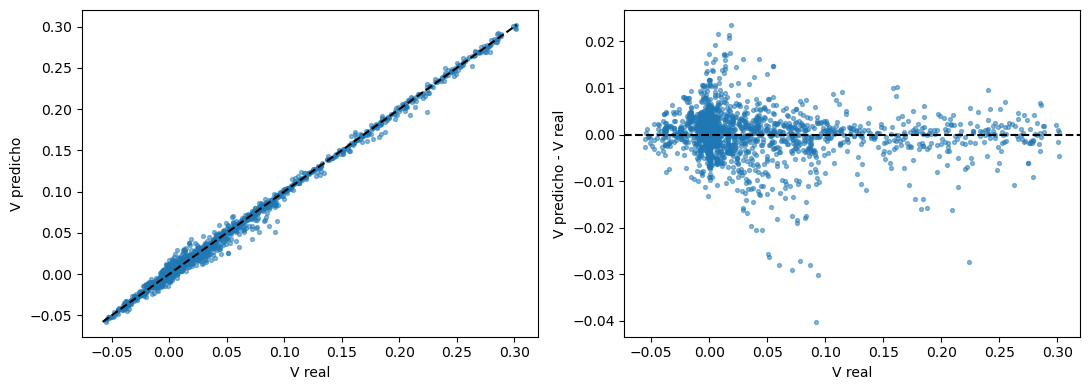

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Predicción frente al valor real
axes[0].scatter(
    V_test_real.ravel(),
    V_pred_test.ravel(),
    s=8,
    alpha=0.5,
)

vmin = min(V_test_real.min(), V_pred_test.min())
vmax = max(V_test_real.max(), V_pred_test.max())

axes[0].plot(
    [vmin, vmax],
    [vmin, vmax],
    color="black",
    linestyle="--",
)

axes[0].set_xlabel("V real")
axes[0].set_ylabel("V predicho")

# Error frente a la energía
axes[1].scatter(
    V_test_real.ravel(),
    errors.ravel(),
    s=8,
    alpha=0.5,
)

axes[1].axhline(0.0, color="black", linestyle="--")
axes[1].set_xlabel("V real")
axes[1].set_ylabel("V predicho - V real")

plt.tight_layout()
plt.show()

In [60]:
import numpy as np
import pandas as pd

test_results = pes.iloc[idx_test].copy()

test_results["V_real"] = V_test_real.ravel()
test_results["V_pred"] = V_pred_test.ravel()
test_results["error"] = (
    test_results["V_pred"] - test_results["V_real"]
)
test_results["abs_error"] = np.abs(test_results["error"])

bins = [
    -np.inf,
    0.00,
    0.05,
    0.10,
    0.15,
    np.inf,
]

labels = [
    "V < 0",
    "0.00–0.05",
    "0.05–0.10",
    "0.10–0.15",
    "V > 0.15",
]

test_results["region"] = pd.cut(
    test_results["V_real"],
    bins=bins,
    labels=labels,
)

summary = (
    test_results
    .groupby("region", observed=False)
    .agg(
        n=("error", "size"),
        RMSE_Ha=(
            "error",
            lambda x: np.sqrt(np.mean(x**2)),
        ),
        MAE_Ha=(
            "error",
            lambda x: np.mean(np.abs(x)),
        ),
        MAX_Ha=(
            "error",
            lambda x: np.max(np.abs(x)),
        ),
    )
)

summary["RMSE_eV"] = summary["RMSE_Ha"] * 27.211386
summary["MAE_eV"] = summary["MAE_Ha"] * 27.211386
summary["MAX_eV"] = summary["MAX_Ha"] * 27.211386

print(summary)

              n   RMSE_Ha    MAE_Ha    MAX_Ha   RMSE_eV    MAE_eV    MAX_eV
region                                                                     
V < 0       633  0.003505  0.002562  0.015469  0.095383  0.069728  0.420924
0.00–0.05  1333  0.004250  0.002682  0.023577  0.115658  0.072984  0.641553
0.05–0.10   232  0.007781  0.004717  0.040285  0.211736  0.128349  1.096220
0.10–0.15    90  0.003230  0.002089  0.011969  0.087898  0.056854  0.325704
V > 0.15    202  0.004664  0.003020  0.027510  0.126923  0.082188  0.748579
